# Time Series Output Analysis by Water Period

This notebook generates comprehensive time series plots segmented by hydrological water periods (Rising - R, High Water - HW, Falling - F, Low Water - LW). Unlike the standard time series notebook, this analysis:
- Filters data for each water period independently
- Applies fixed color coding per water period (Red: R, Orange: HW, Blue: F, Green: LW)
- Generates separate figures for each water period and watershed combination
- Includes trend analysis with R² statistics for each period subset

All plots are generated for both regional and local watersheds across all four water periods.

In [ ]:
# Import required libraries for data processing and visualization
import matplotlib.pyplot as plt  # Plotting library
import numpy as np  # Numerical operations
import pandas as pd  # Data manipulation and reading CSV files
import glob  # File path pattern matching
import os  # Directory and file operations

## 1. Configure Working Directory

Set the path to the merged dataframe directory containing the time series data files for both regional and local watersheds.

In [68]:
data_dir = r"C:/Users/l_v_v/Documents/GitHub/time_series_curuai/datasets/Parameters Time series/merged_df"

## 2. Configure Plotting Parameters

Define standard visualization settings for consistency across all plots in the notebook.

In [ ]:
# Configure matplotlib visualization parameters for consistency across all plots
plt.rcParams['font.size'] = 15  # Base font size for readability

## 3. Define Core Plotting Function (Water-Period Specific)

The `prepare_time_series_plot_wp()` function reads paired CSV files containing time series data and trend analysis, then generates publication-quality plots segmented by water period with:
- Fixed color mapping for water periods (Red: R, Orange: HW, Blue: F, Green: LW)
- Data filtering for specific water period subset
- Linear regression analysis with R² goodness-of-fit
- Automated trend annotation (Positive/Negative Linear/Monotonic)

In [ ]:
def prepare_time_series_plot_wp(paths_var, paths_trend, dict_var, data_dir, color_palette=None):
    """Read paired time-series and trend CSVs and plot them by water period.

    Parameters
    ----------
    paths_var : list
        List of CSV filepaths containing time series data (must contain 'time_start' and variables)
    paths_trend : list
        List of CSV filepaths with trend information for a specific water period
    dict_var : dict
        Mapping of variable names to {'title': str, 'label': str} for plot annotations
    data_dir : str
        Base directory (used only for path context)
    color_palette : list, optional
        List of colors for water period visualization (default: red, orange, blue, green)
    """

    # ========== 1. Setup Fixed Color Mapping for Water Periods ==========
    if color_palette is None:
        # Standard colors: Red (R), Orange (HW), Blue (F), Green (LW)
        color_vals = ['#d62728', '#ff7f0e', '#1f77b4', '#2ca02c']
    else:
        color_vals = color_palette
    
    # Map each water period to its fixed color for consistent visualization across plots
    period_order = ["R", "HW", "F", "LW"]  # Rising, High Water, Falling, Low Water
    fixed_colors = {p: color_vals[i % len(color_vals)] for i, p in enumerate(period_order)}

    # ========== 2. Process Each Pair of Time Series and Trend Files ==========
    for p_var, p_trend in zip(paths_var, paths_trend):
        # Read time series data and sort by date
        df = pd.read_csv(p_var, parse_dates=['time_start']).sort_values('time_start')

        # Load trend data robustly with error handling for encoding issues
        try:
            df_trend = pd.read_csv(p_trend)
        except Exception:
            df_trend = pd.read_csv(p_trend, encoding='utf-8', engine='python')

        # Clean up trend dataframe
        if 'Unnamed: 0' in df_trend.columns:
            df_trend = df_trend.drop(columns=['Unnamed: 0'])
        if 'variable' in df_trend.columns:
            df_trend = df_trend.set_index('variable')

        # ========== 3. Extract Water Period from Filename and Filter Data ==========
        # Water period is extracted from the trend file name (e.g., "R.csv", "HW.csv", "F.csv", "LW.csv")
        w_p = os.path.basename(paths_trend[0]).split("_")[-1].split(".")[0]
        
        # Filter dataframe to only include records for this specific water period
        if 'water_period' in df.columns:
            df = df.loc[df['water_period'] == w_p].copy()
            df = df.reset_index(drop=True)
        
        print(f"Plotting for period: {w_p} | Records: {len(df)}")

        # ========== 4. Prepare Variables for Plotting ==========
        # Use all variables defined in dict_var to ensure comprehensive coverage
        axes = list(dict_var.keys())

        if not axes:
            print("No variables found in dictionary.")
            continue

        # ========== 5. Create Subplot Layout (One Row Per Variable) ==========
        fig, axs = plt.subplots(len(axes), 1, figsize=(16, 3 * len(axes)), squeeze=False)

        # ========== 6. Plot Each Variable ==========
        for i, var in enumerate(axes):
            ax = axs[i, 0]

            # Check if variable exists in time series data
            if var not in df.columns:
                ax.text(0.5, 0.5, f"{var} not in data columns", ha='center')
                continue

            # Retrieve the fixed color for this water period
            plot_color = fixed_colors.get(w_p, 'black')

            # ========== 7. Data Preparation and Raw Series Plotting ==========
            series = df[var]
            x = df['time_start']
            
            # ========== 8. Special Handling for Land Cover Area Variables ==========
            if ("anthropogenic_km2" in var) or ("natural_km2" in var):
                # Drop duplicate time values for area variables (yearly estimates)
                drop_duplicates = df.drop_duplicates(subset=[var])
                series = drop_duplicates[var]
                x = drop_duplicates['time_start']
                
                # Plot raw data with dashed line and markers
                ax.plot(x, series, color='gray', linestyle='-.', linewidth=1, alpha=0.6)
                ax.plot(x, series, marker='o', linestyle='none', markersize=6, 
                        color=plot_color, alpha=0.8, label=f"{w_p} Yearly Estimates")
            
            # ========== 9. Standard Time Series Plotting ==========
            else:
                # Plot raw time series with dashed line and light color
                ax.plot(x, series, color='gray', linestyle='-.', linewidth=1, alpha=0.6)
                # Plot data points with water-period-specific color
                ax.plot(x, series, marker='o', linestyle='none', markersize=6, 
                        color=plot_color, alpha=0.8, label=str(w_p))

            # ========== 10. Linear Trend Line Calculation ==========
            # Convert dates to ordinal for linear regression
            x_ord = x.map(pd.Timestamp.toordinal)
            valid = series.notna() & x_ord.notna()

            # Initialize trend parameters
            m, b = np.nan, np.nan
            if valid.sum() > 1:
                try:
                    m, b = np.polyfit(x_ord[valid], series[valid], 1)
                    # Plot trend line
                    ax.plot(x, m * x_ord + b, color='black', linestyle='--', linewidth=1)
                except Exception as e:
                    print(f"Could not fit line for {var}: {e}")

            # ========== 11. Axis Labels and Formatting ==========
            ax.set_xlabel('Date')
            ax.set_ylabel(dict_var.get(var, {}).get('label', var))

            # ========== 12. Trend Annotation and Statistics ==========
            # Retrieve trend text from trend analysis if available
            trend_text = ''
            if var in df_trend.index:
                try:
                    val = df_trend.loc[var, 'trend']
                    # Handle case where val might be NaN or not a string
                    if pd.notna(val):
                        trend_text = str(val)
                except Exception:
                    trend_text = ''
            
            # ========== 13. Build Annotation String with Multiple Components ==========
            anno_parts = []
            a1 = ''  # Regression equation
            a2 = ''  # Trend classification
            b1 = ''  # R-squared and sample size
            
            # Build regression equation line if trend was calculated
            if not np.isnan(m):
                a1 = f"y = {m:.3f}x + {b:.3f}"
                # Calculate R-squared (coefficient of determination)
                b1 = f"R² = {1 - (np.sum((series[valid] - (m * x_ord[valid] + b)) ** 2) / np.sum((series[valid] - series[valid].mean()) ** 2)):.3f}" if valid.sum() > 1 else ""
            
            # Build trend classification line based on slope and trend type
            if trend_text:
                a2 = f" ({'Positive Monotonic Trend' if ((trend_text == 'monotonic') and (m > 0)) else 'Negative Monotonic Trend' if ((trend_text == 'monotonic') and (m < 0)) else 'Positive Linear Trend' if ((trend_text == 'linear') and (m > 0)) else 'Negative Linear Trend' if ((trend_text == 'linear') and (m < 0)) else 'No-Trend'})"
            
            # Combine annotation parts
            if a1 or a2:
                anno_parts.append(a1 + a2)
            if b1:
                anno_parts.append(b1 + f" (n = {int(series.count())})")

            # ========== 14. Display Annotation ==========
            if anno_parts:
                final_text = "\n".join(anno_parts)
                ax.annotate(final_text, 
                           xy=(0.01, 0.915), xycoords='axes fraction', fontsize=13)

        # ========== 15. Save and Display Figure ==========
        plt.tight_layout()
        # Filename includes water period designation
        sv_path = os.path.join(f"{os.path.dirname(p_trend)}", 
                              f"ts_{w_p}_{os.path.basename(p_var).split('_')[-1].replace('.csv', '.jpeg')}")
        plt.savefig(sv_path, dpi=350)
        plt.show()
        plt.close(fig)

## 4. Define Variable Metadata & Formatting

Create a dictionary mapping variable names to their display titles and axis labels. This ensures consistent labeling across all plots.

In [ ]:
# Define metadata for all variables to be plotted
# Each variable entry contains: title (for reference) and label (for y-axis labels with proper units)
dict_var = {
    "TSS_mean": {"title": "TSS", 'label': "TSS (mg/L)"},
    "area_km2": {"title": "Water Surface Area", 'label': "Area (km$^2$)"},
    "precipitation": {"title": "Precipitation", 'label': "Accumulated Precipitation\n(total mm/Hidrological Period)"},
    'u_wind': {"title": "Eastward Wind Speed", 'label': "Eastward Mean Wind Speed\n(m/s)"},
    "v_wind": {"title": "Northward Wind Speed", 'label': "Northward Mean Wind Speed\n(m/s)"},
    'anthropogenic_km2': {"title": "Anthropic Area", 'label': "Anthropic Area (km²)"},
    'natural_km2': {"title": "Natural Area", 'label': "Natural Area (km²)"},
    "mean_discharge": {"title": "Discharge", 'label': "Mean Discharge (m$^3$/s)"}
}

## 5. Generate Water-Period Segmented Time Series Plots

Execute the plotting function for all water periods and both watersheds. This nested loop will:
1. Iterate through regional and local watersheds
2. For each watershed, process all four water periods (R, HW, F, LW)
3. Generate separate multi-panel figures for each water period
4. Apply fixed color coding: Red (R) | Orange (HW) | Blue (F) | Green (LW)
5. Save high-resolution figures to the trend analysis directory
6. Display plots inline with data record count for validation


regional

R
Plotting for period: R | Records: 34


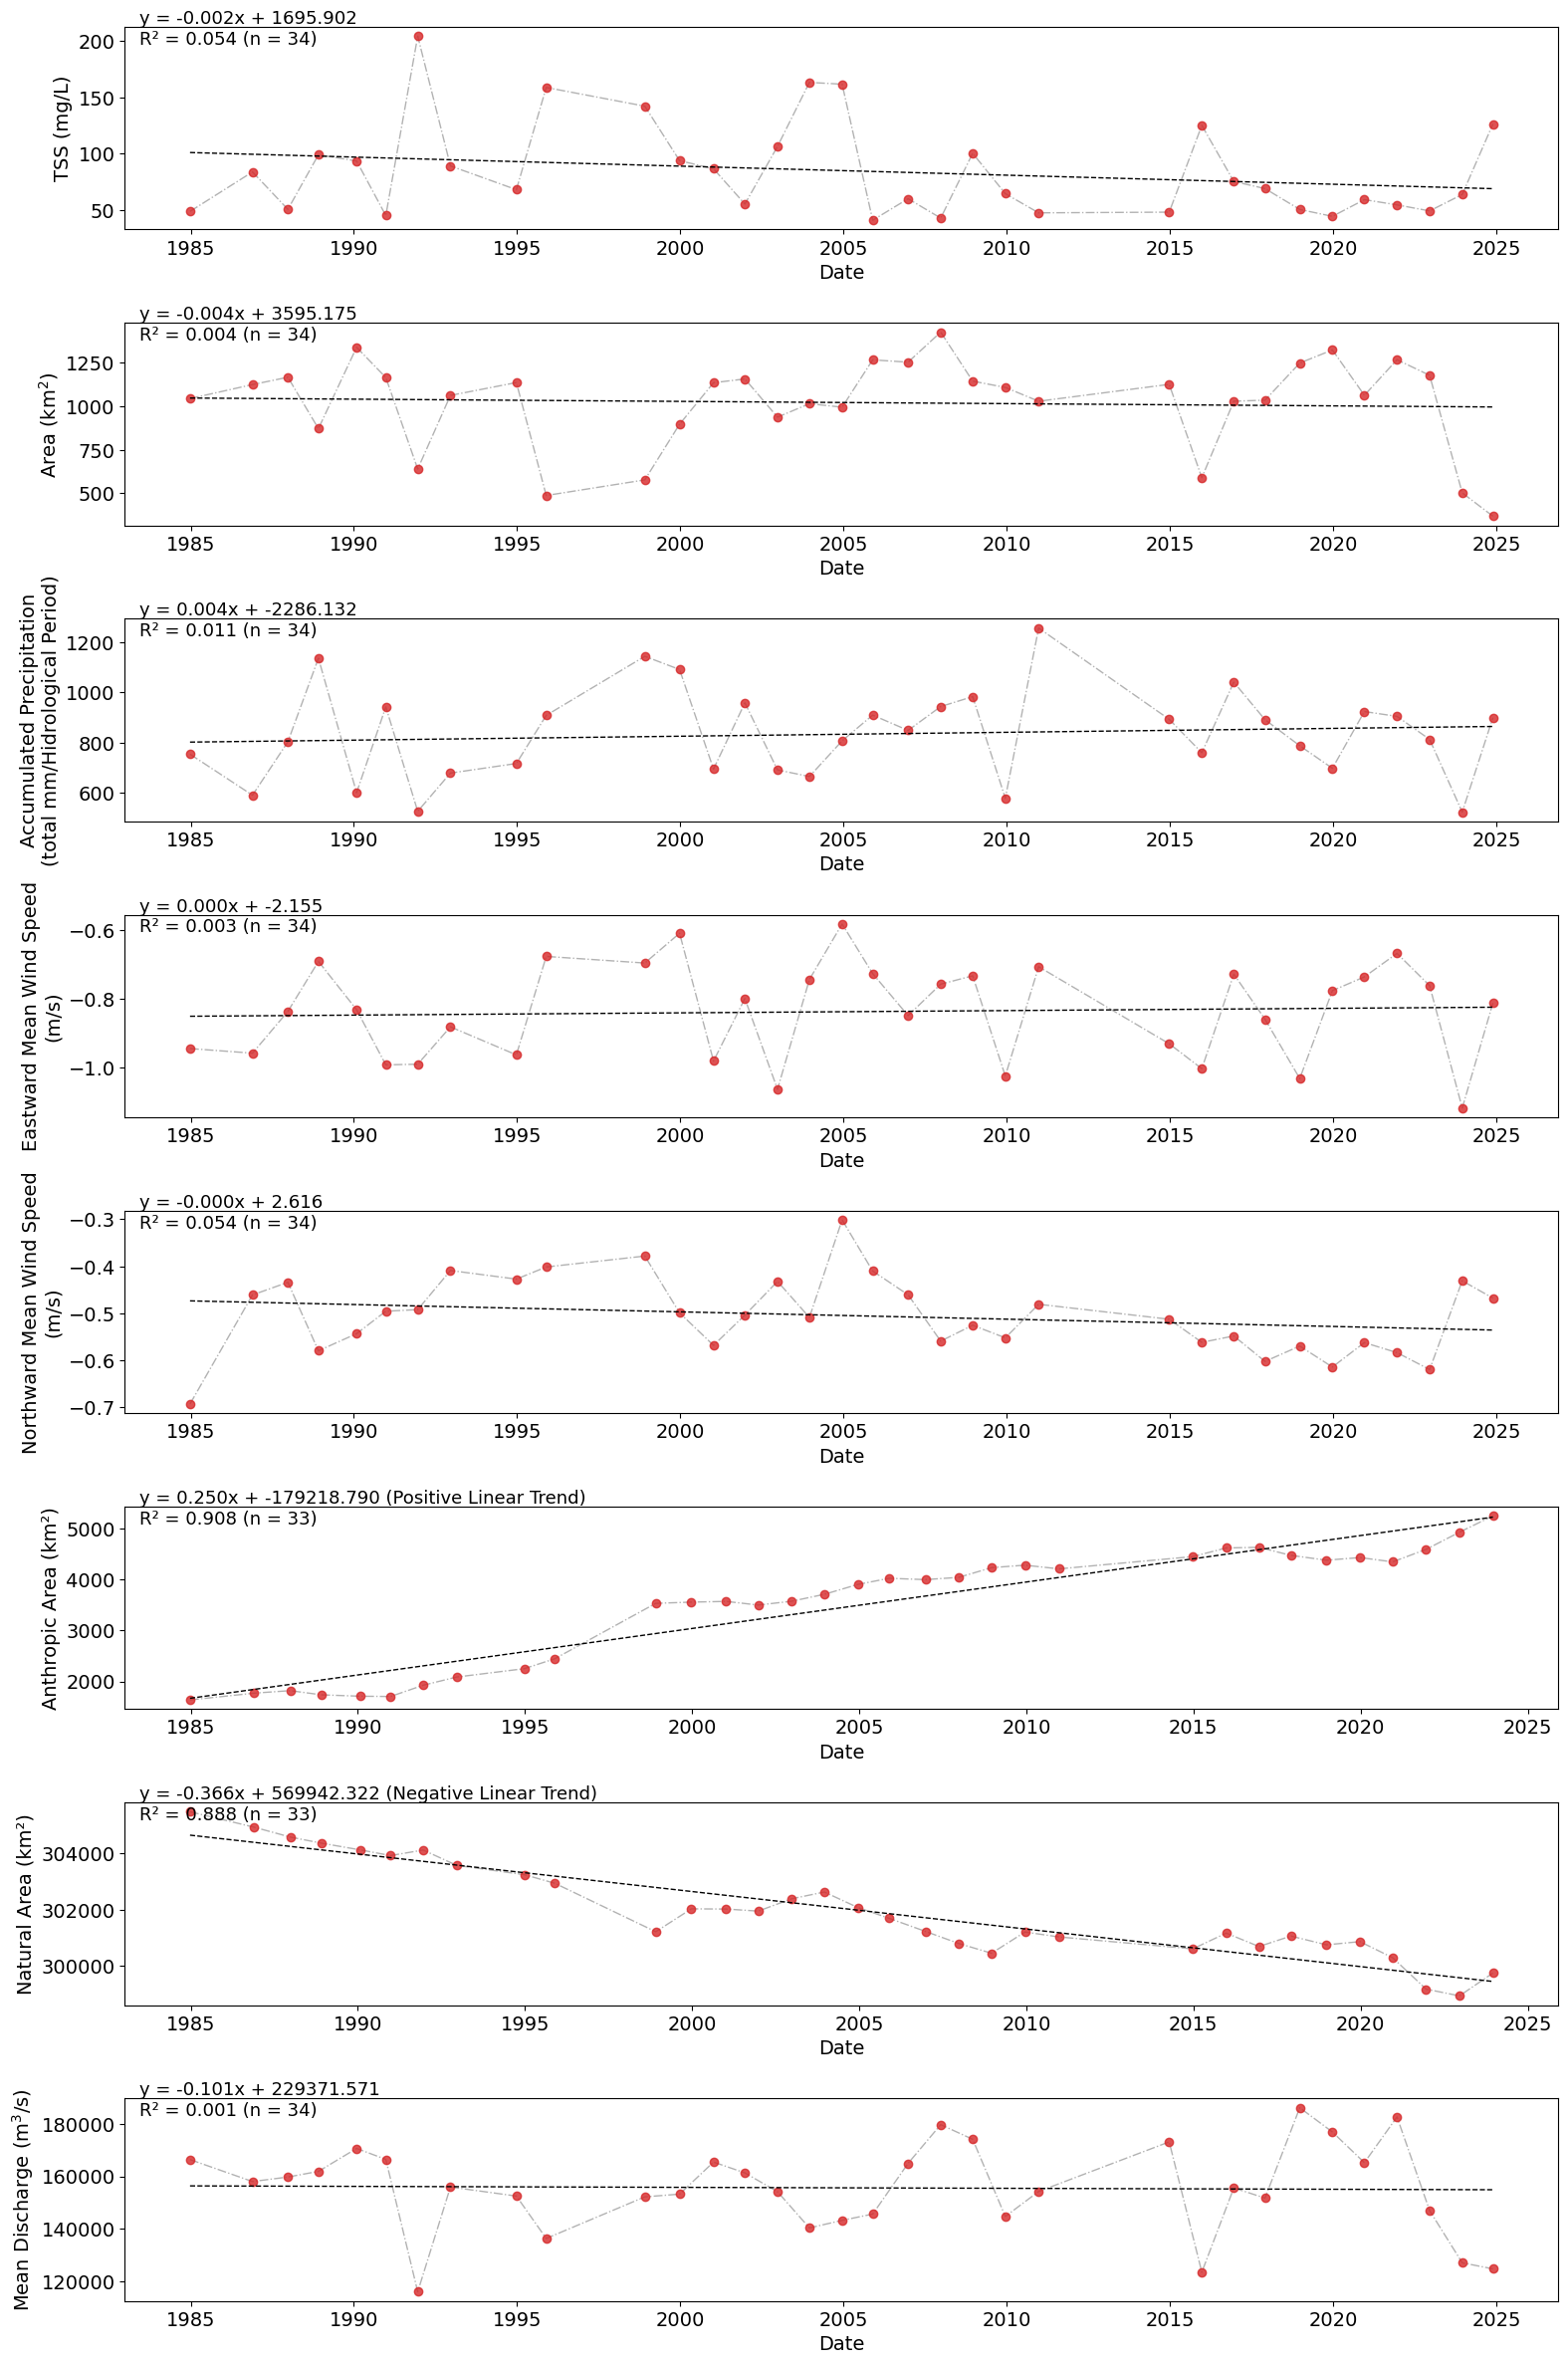


HW
Plotting for period: HW | Records: 35


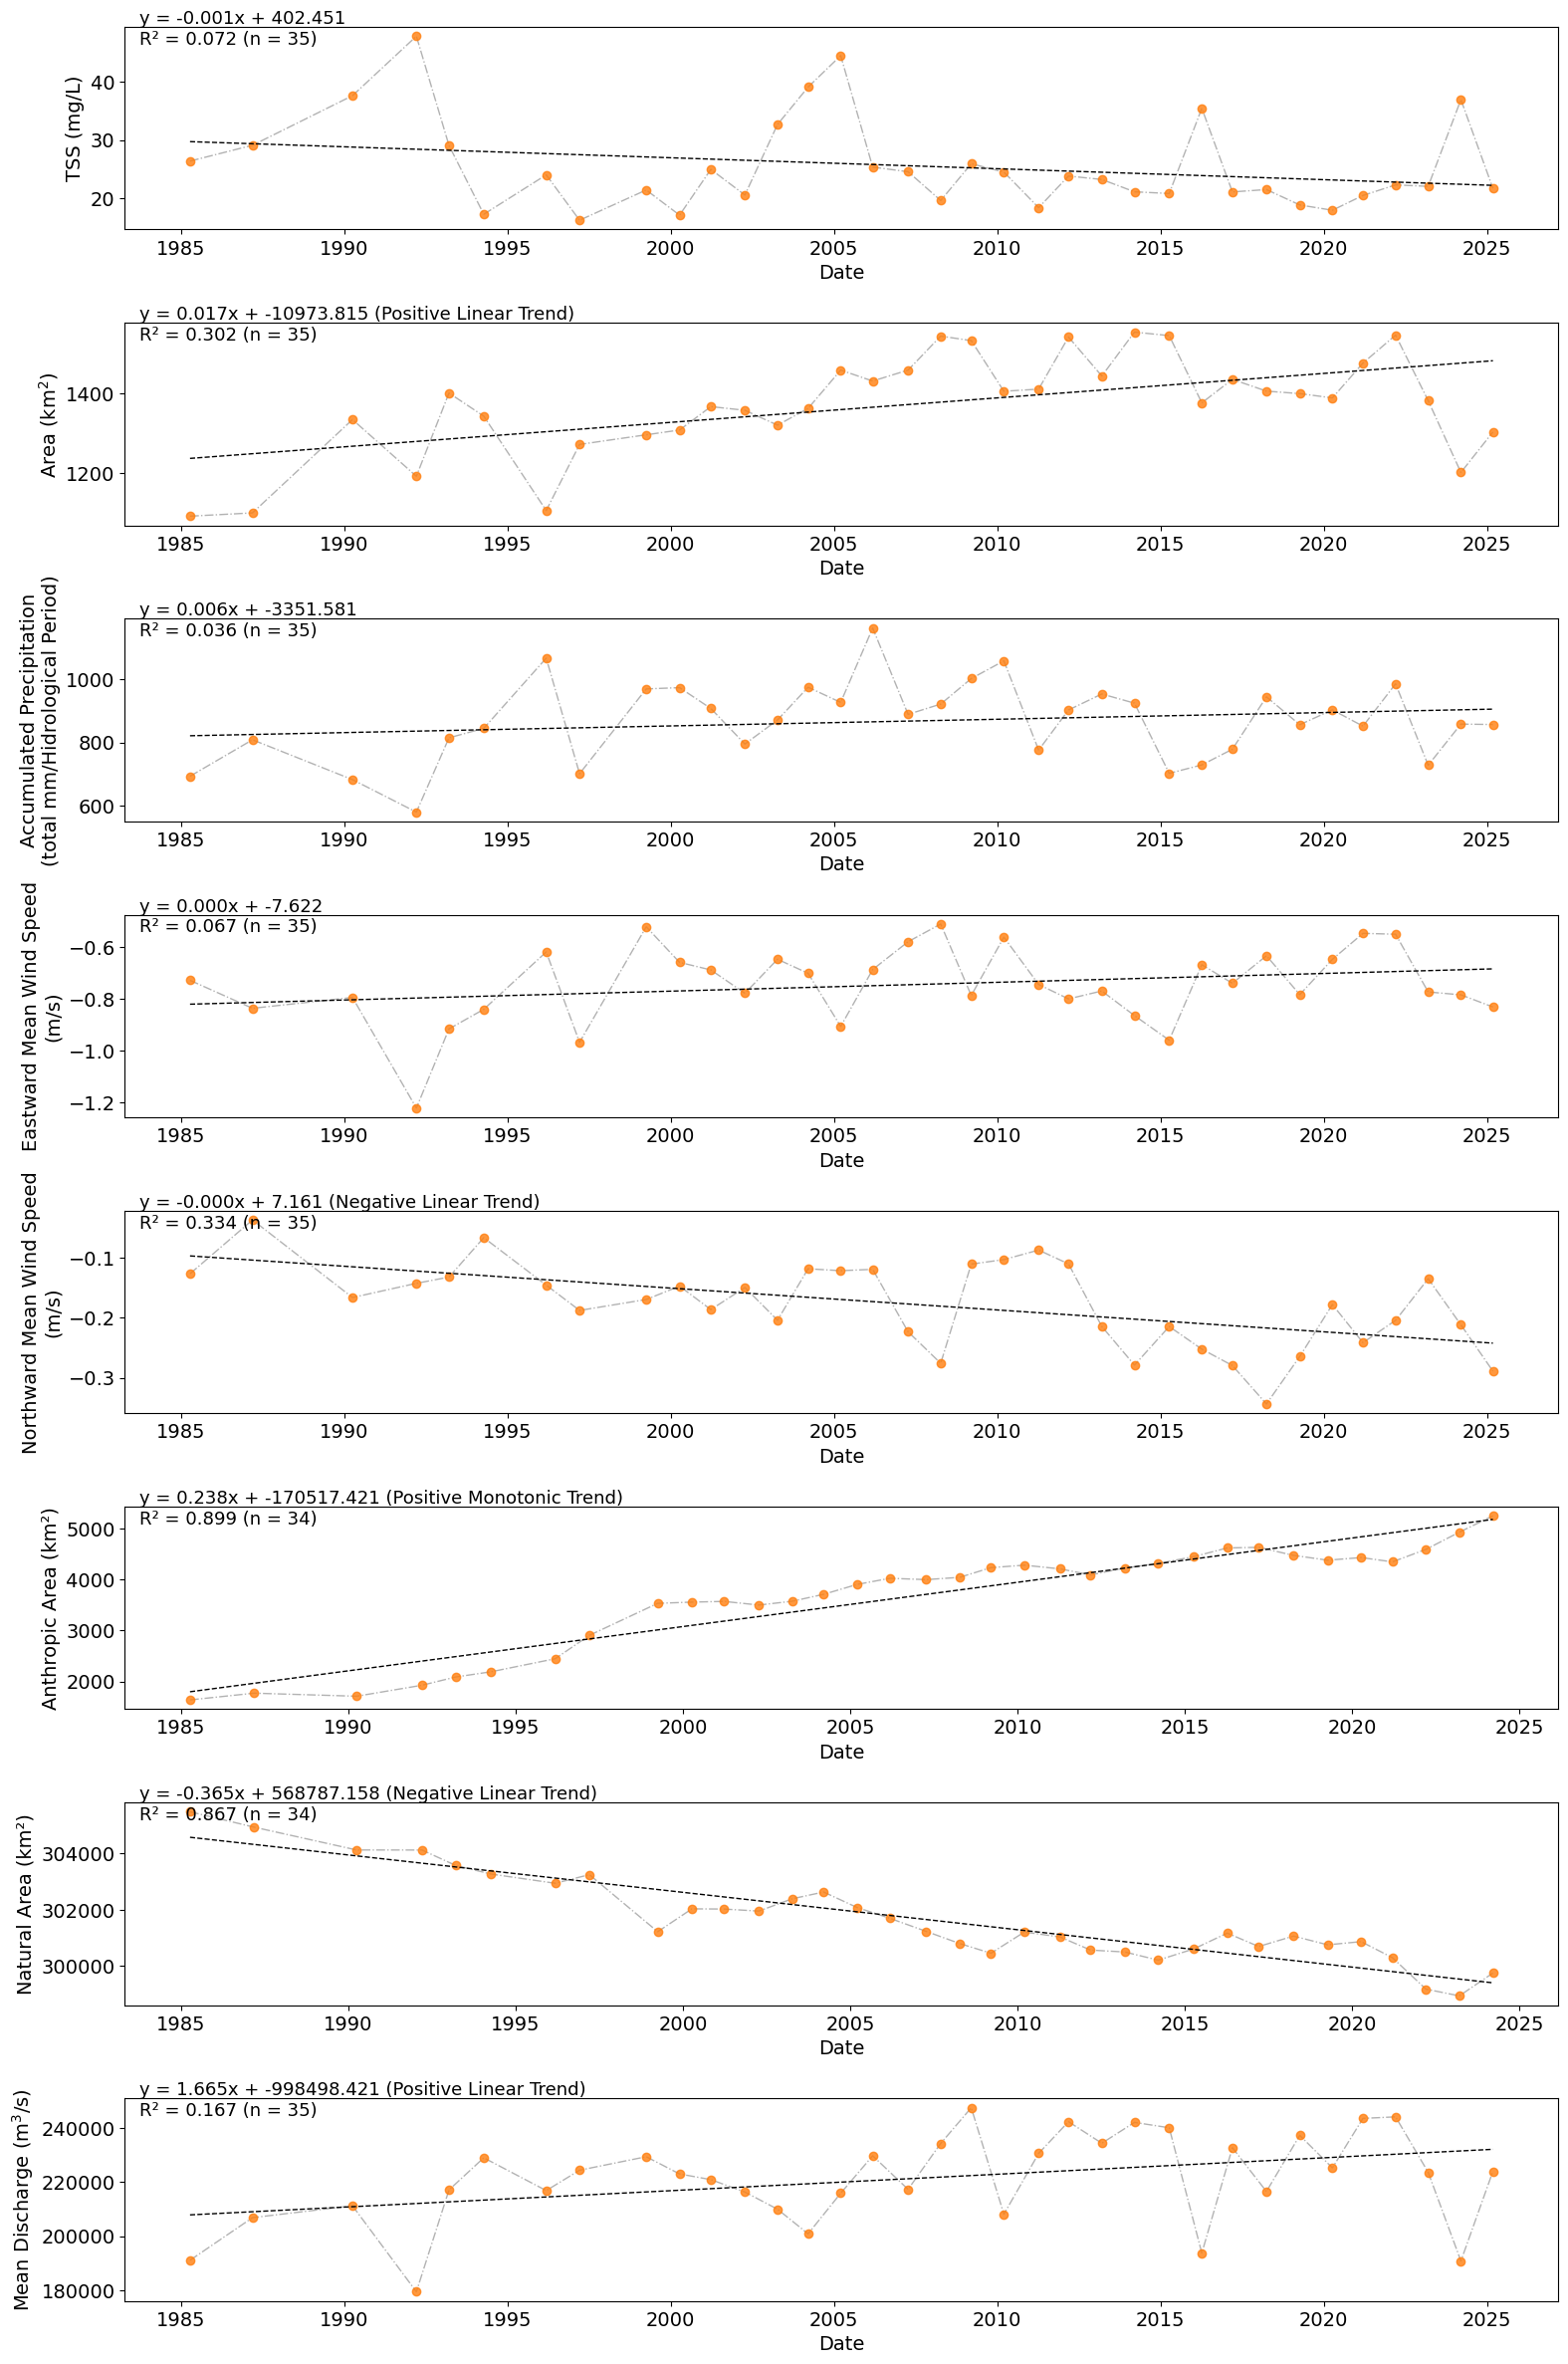


F
Plotting for period: F | Records: 41


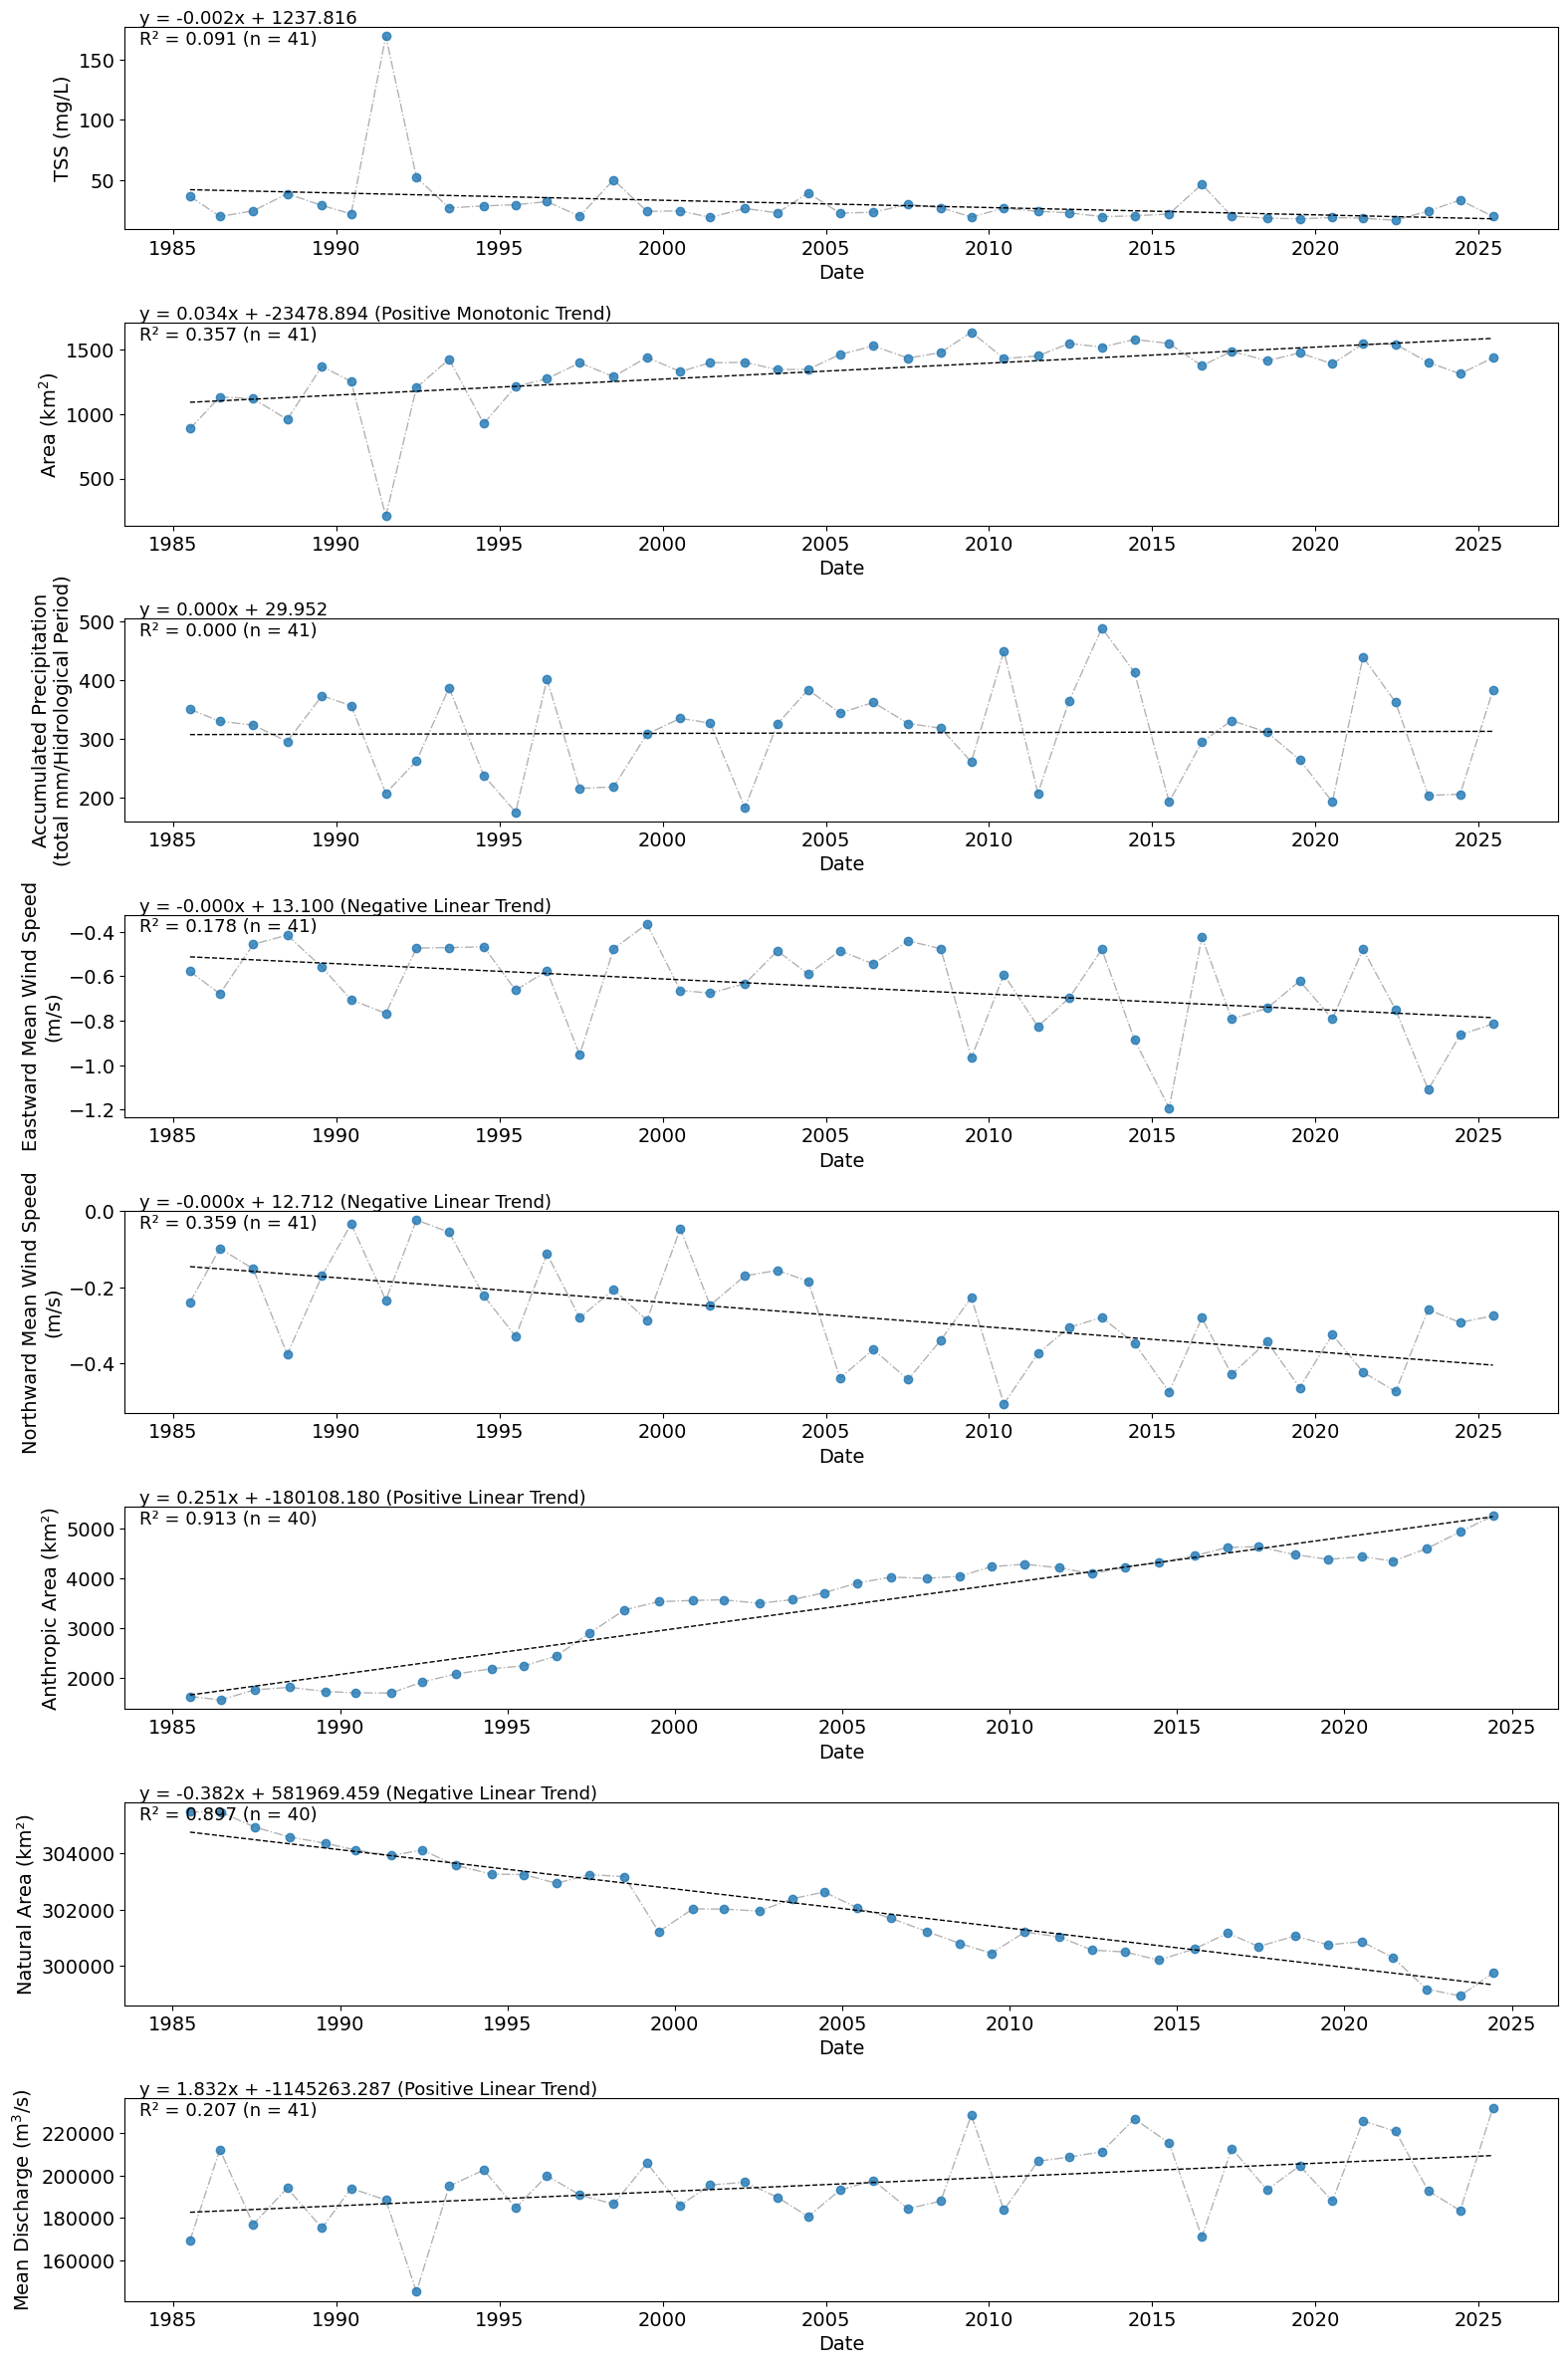


LW
Plotting for period: LW | Records: 37


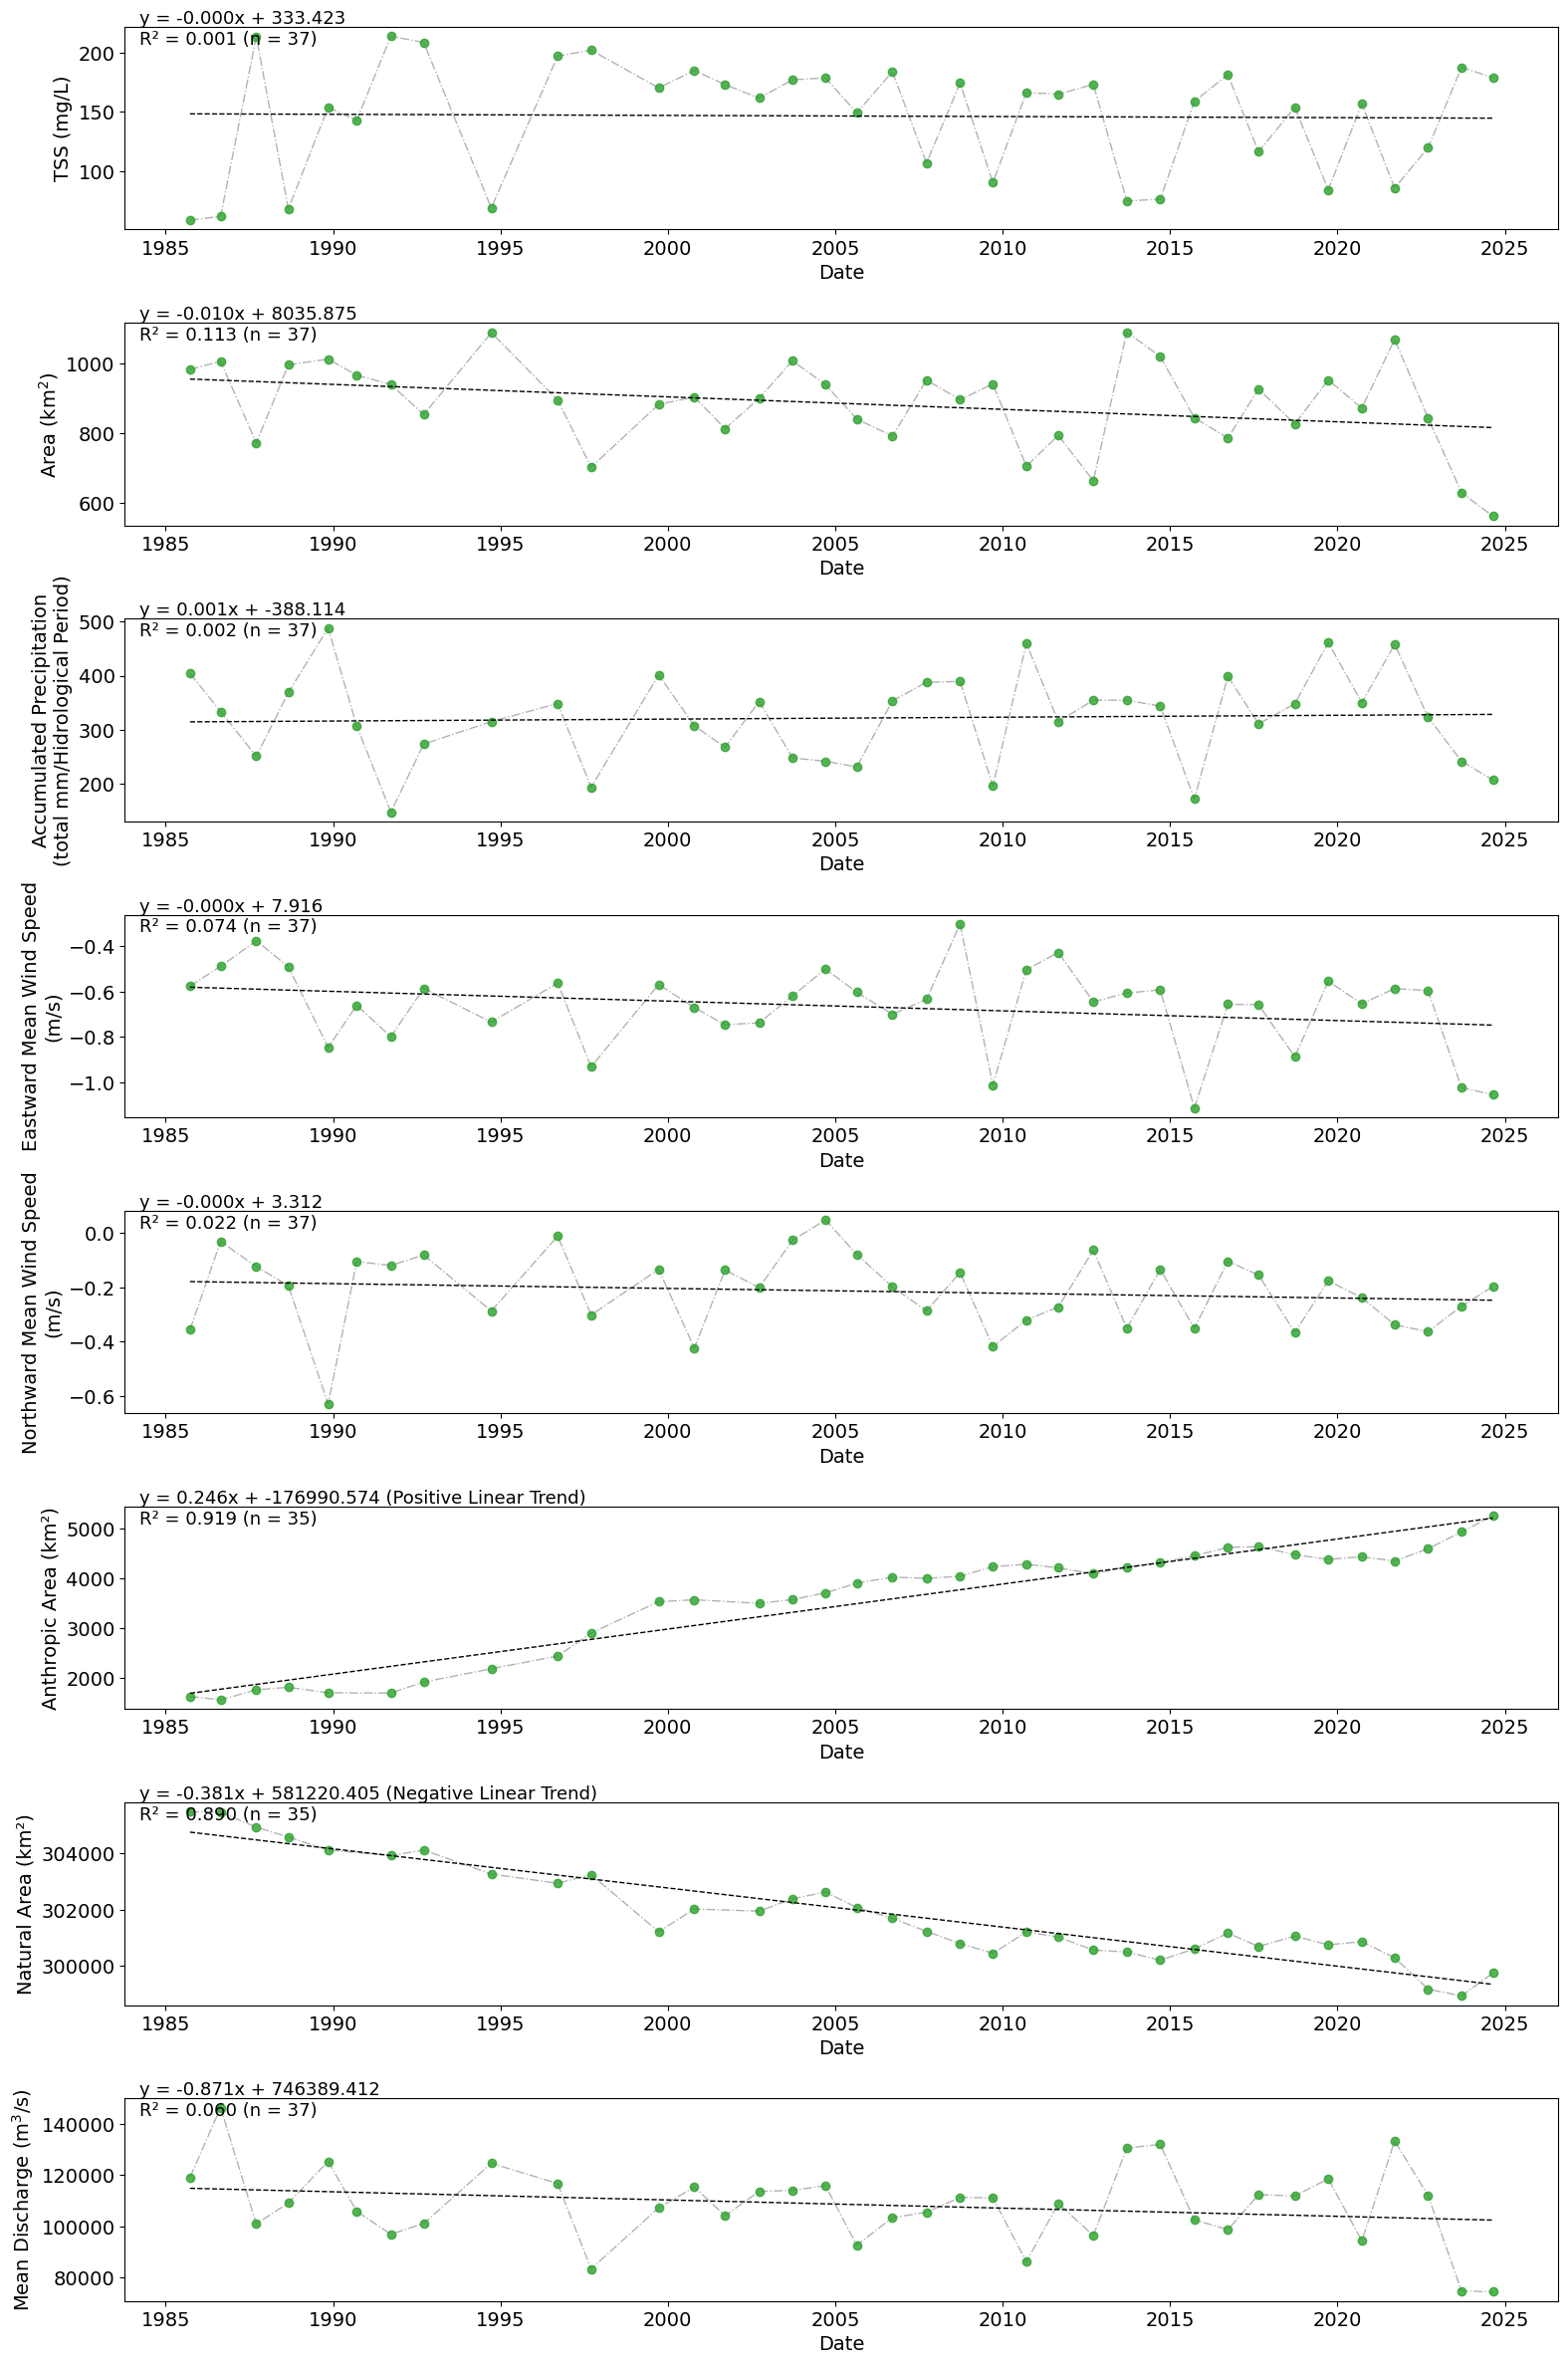


local

R
Plotting for period: R | Records: 34


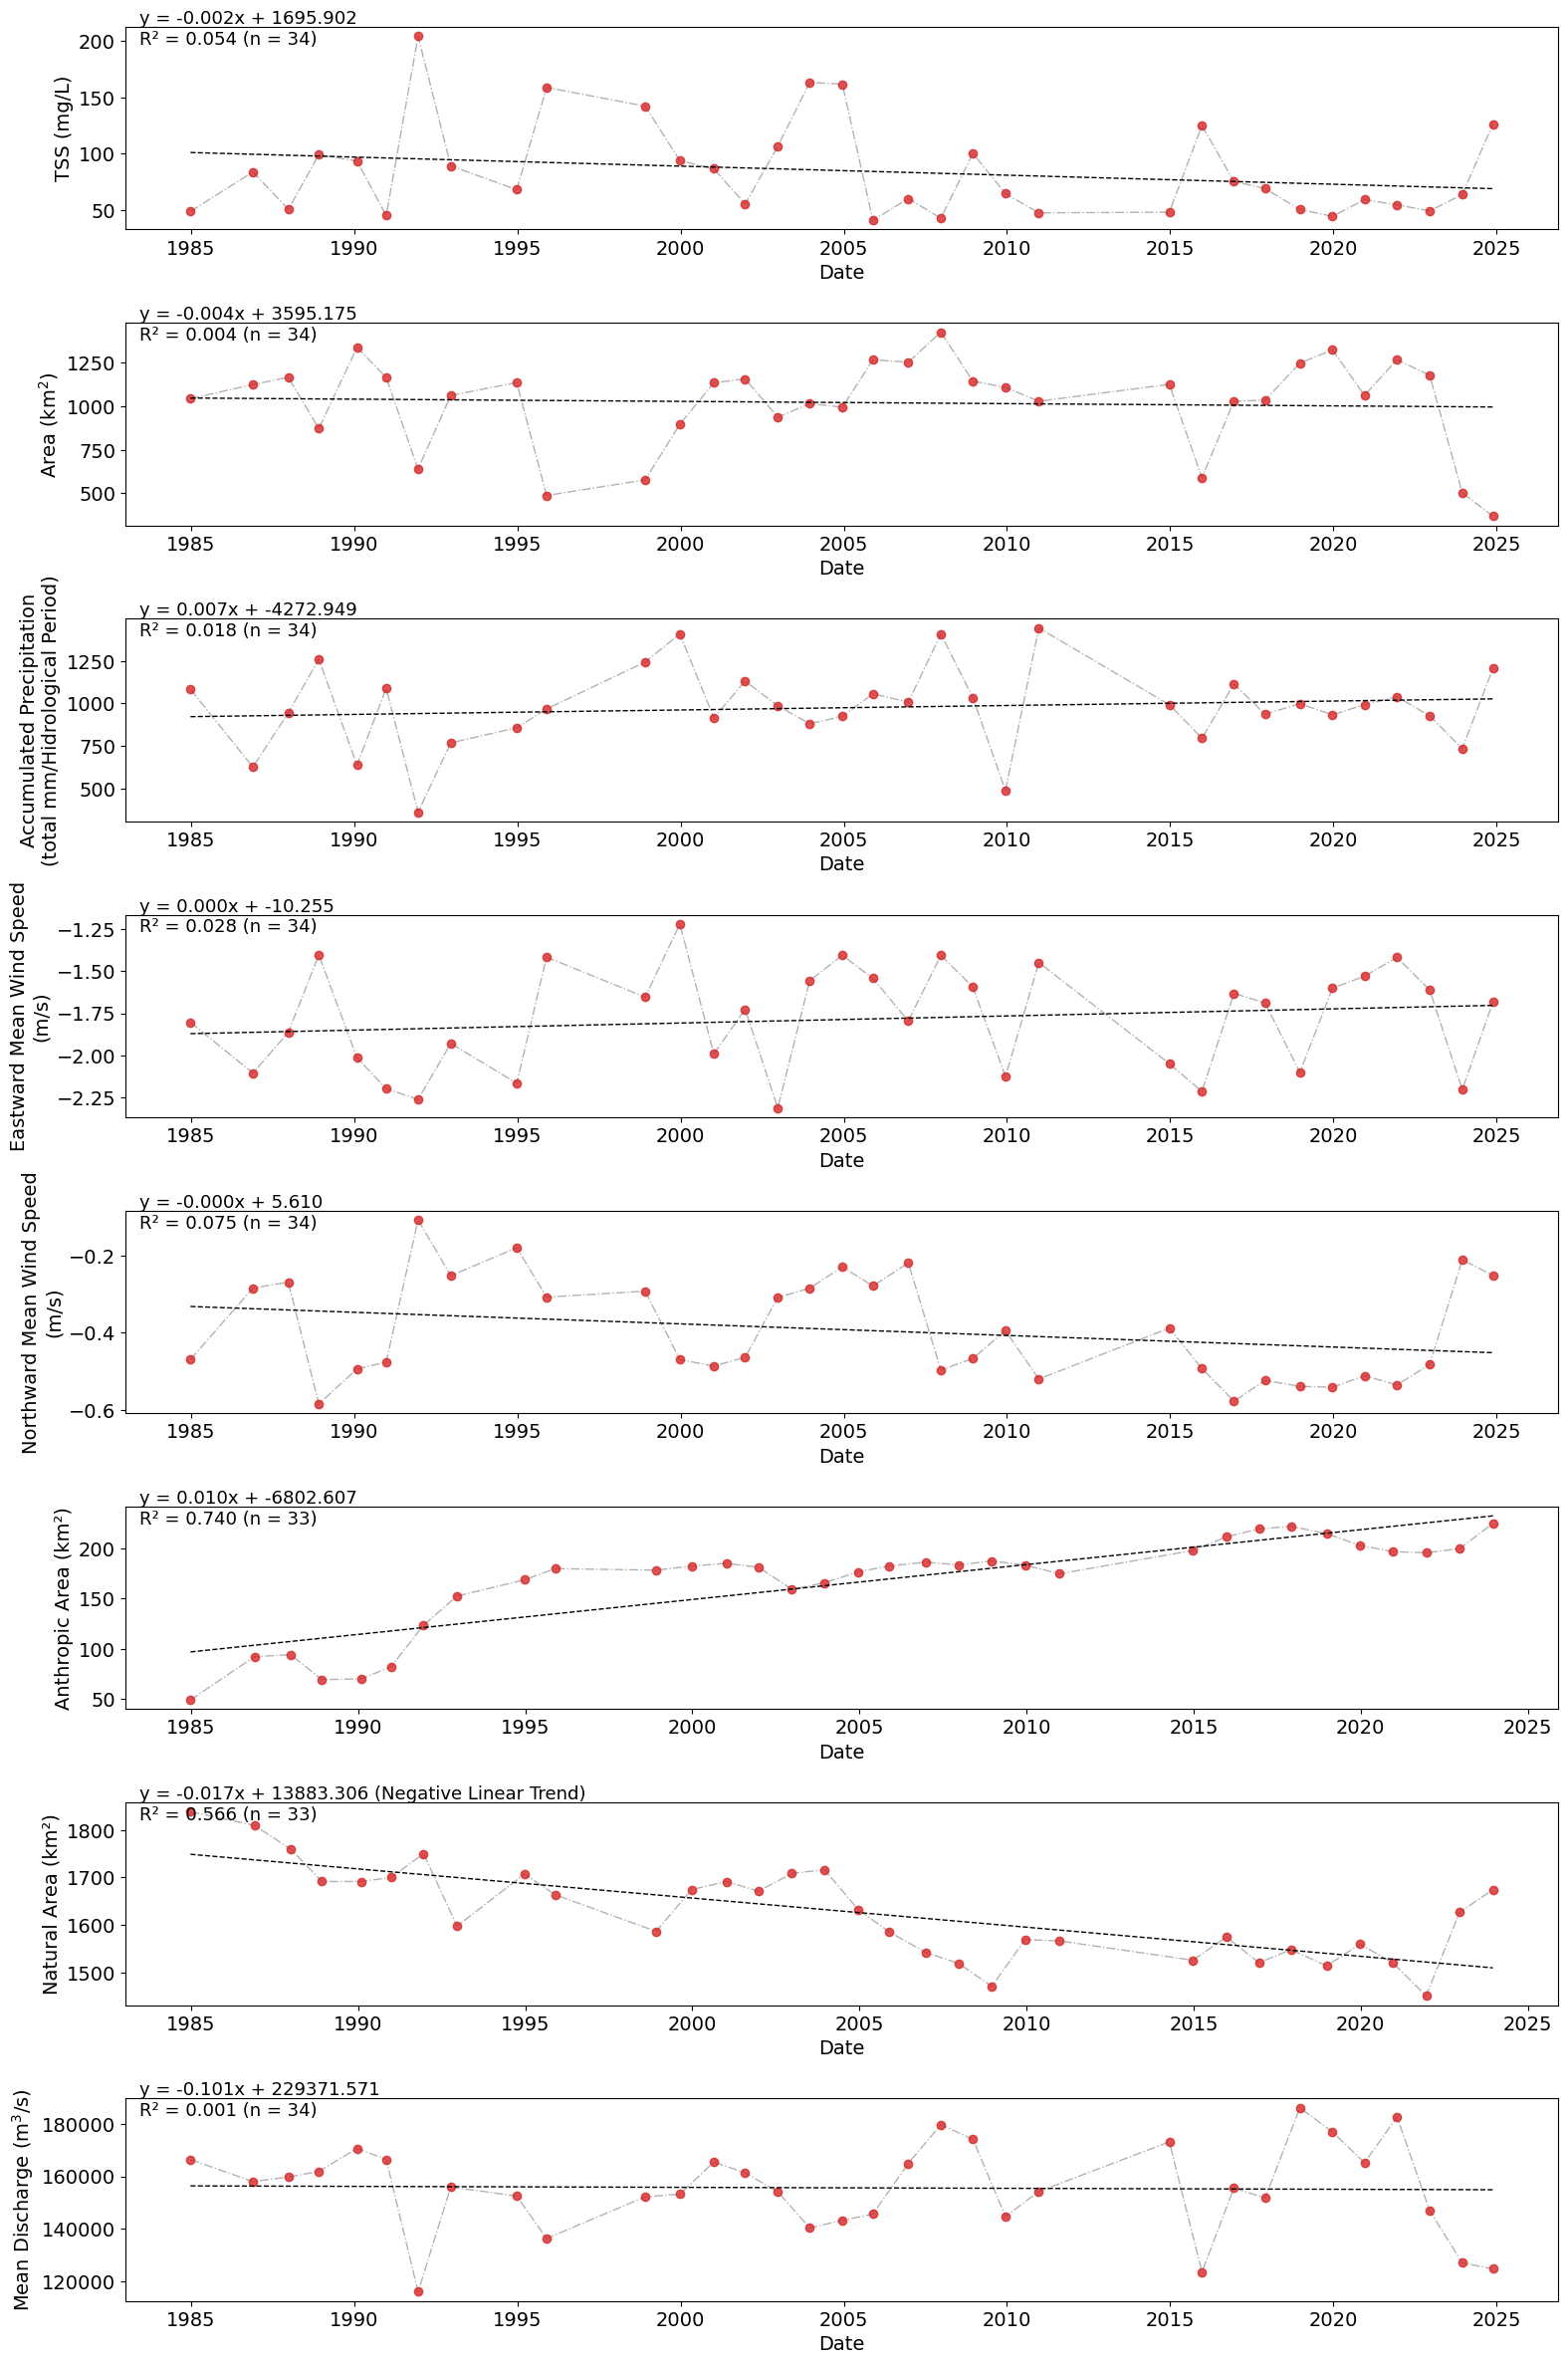


HW
Plotting for period: HW | Records: 35


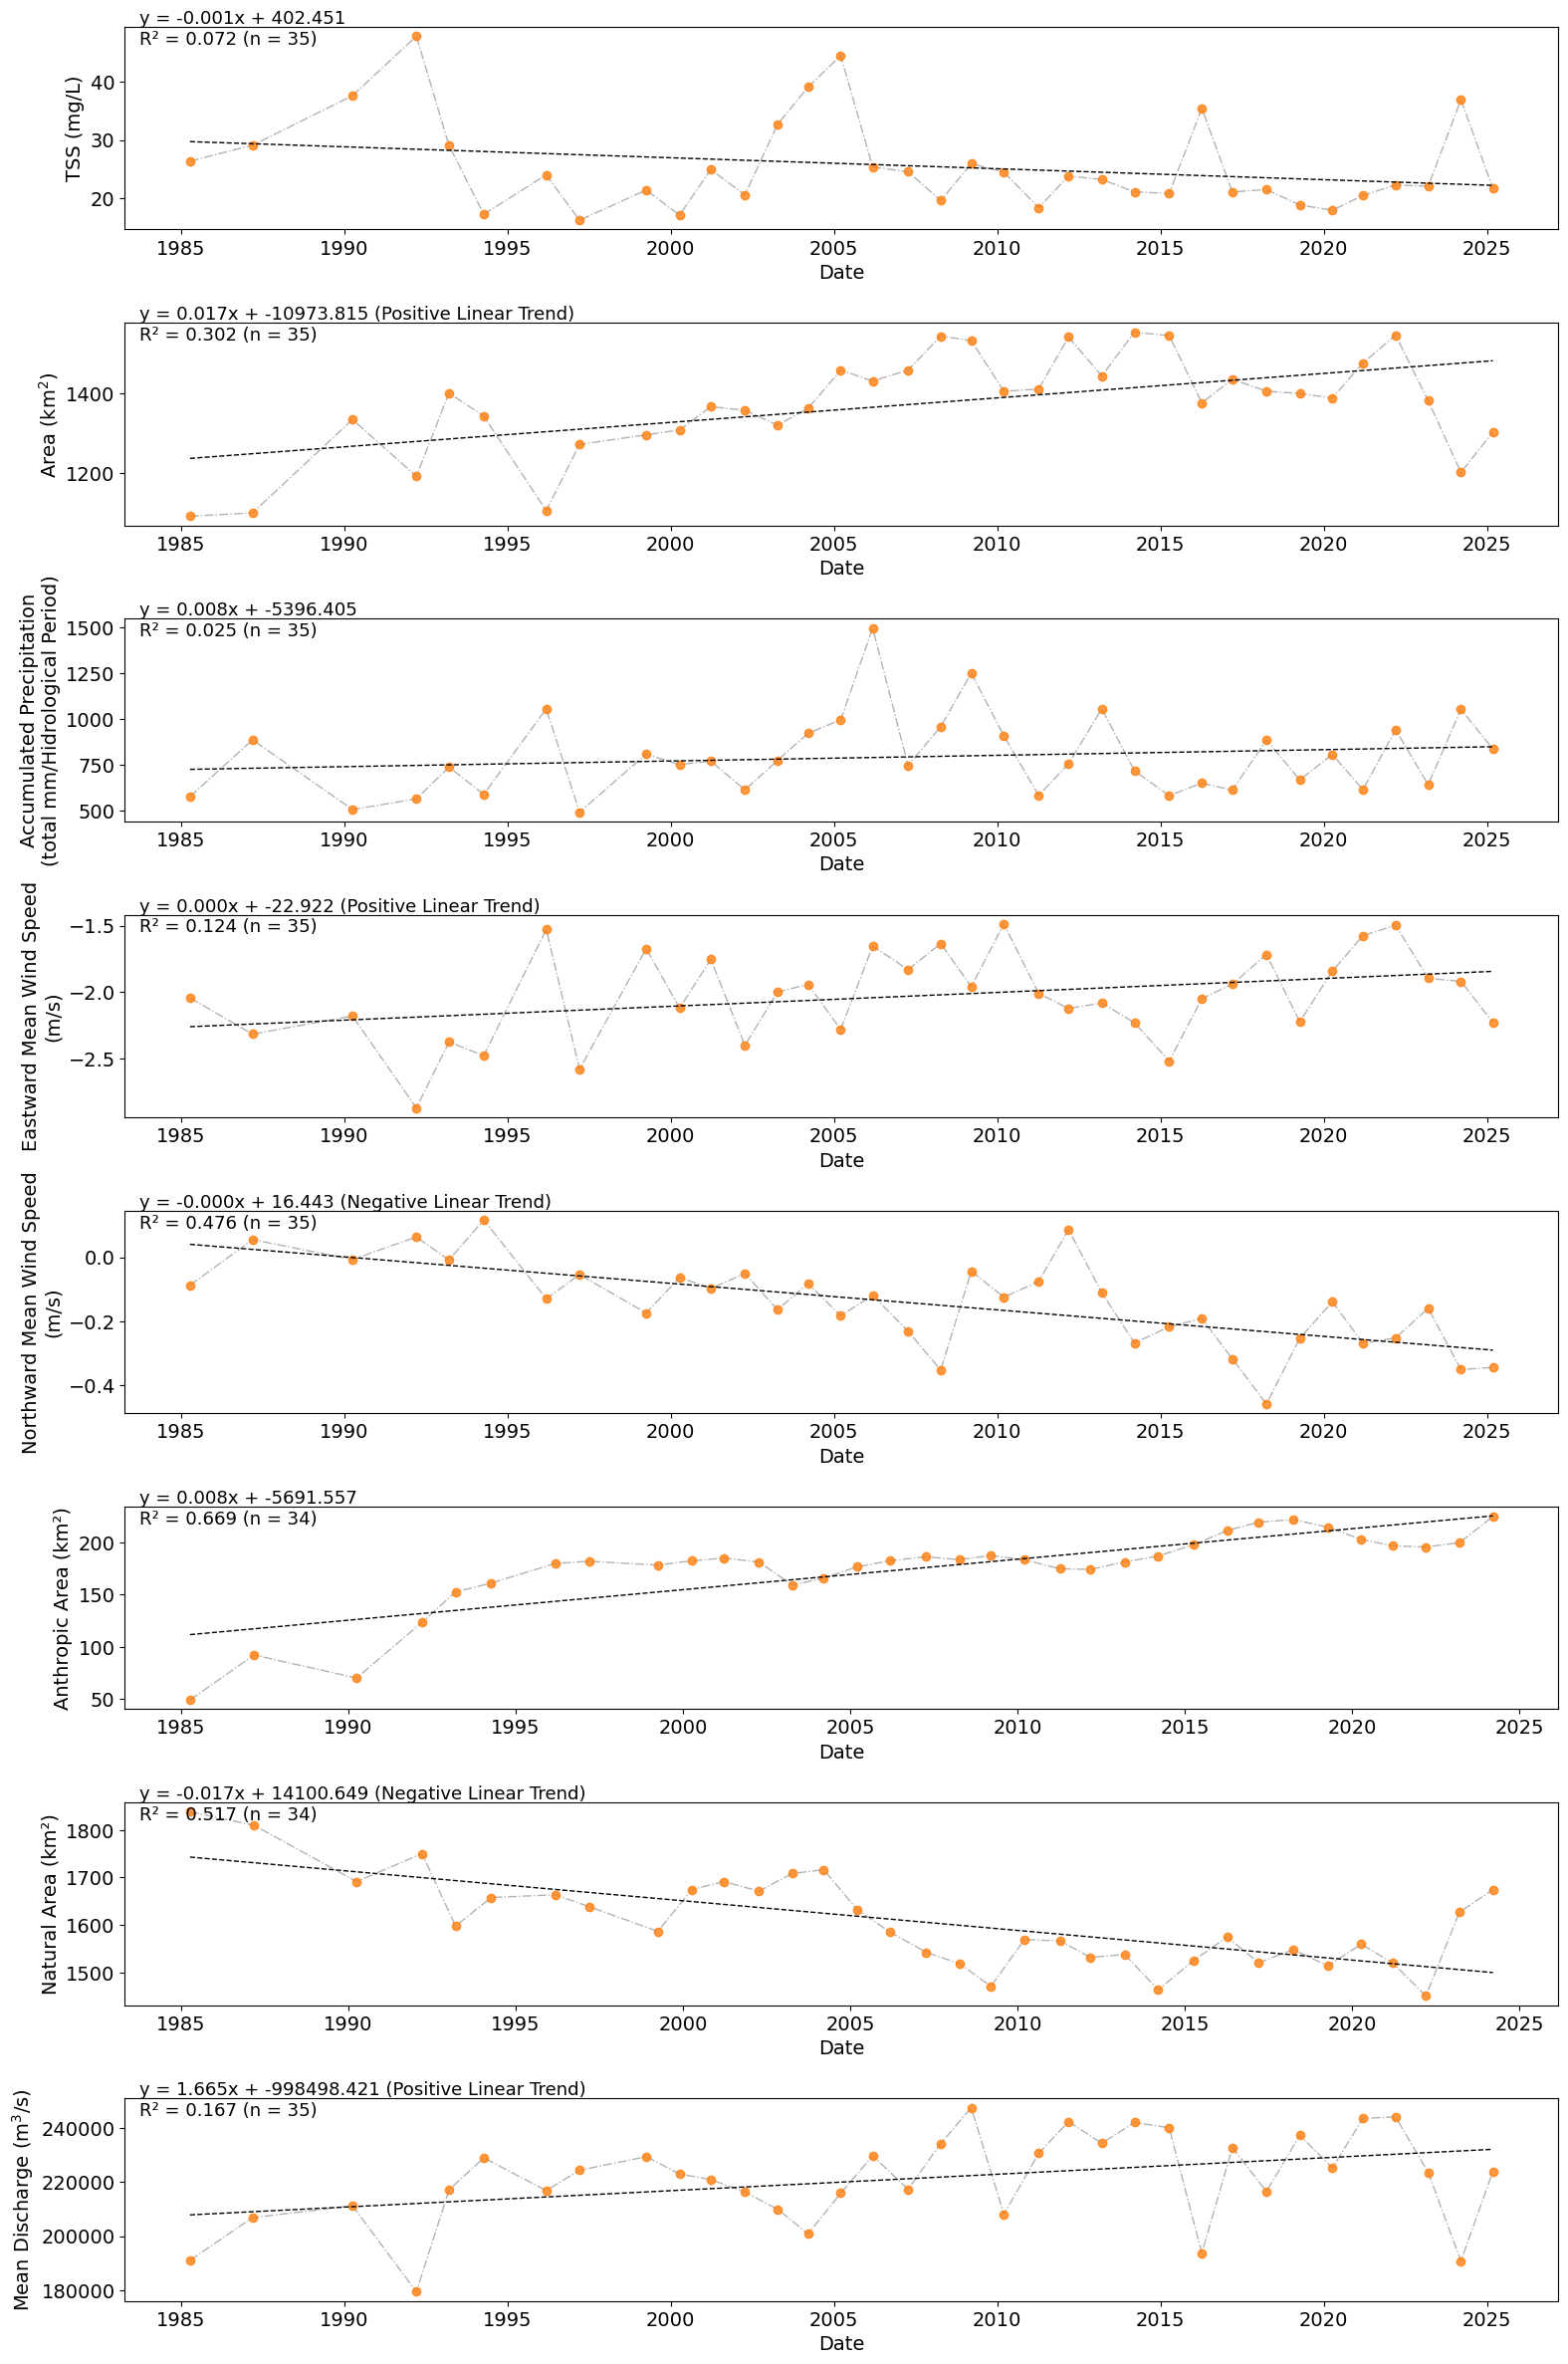


F
Plotting for period: F | Records: 41


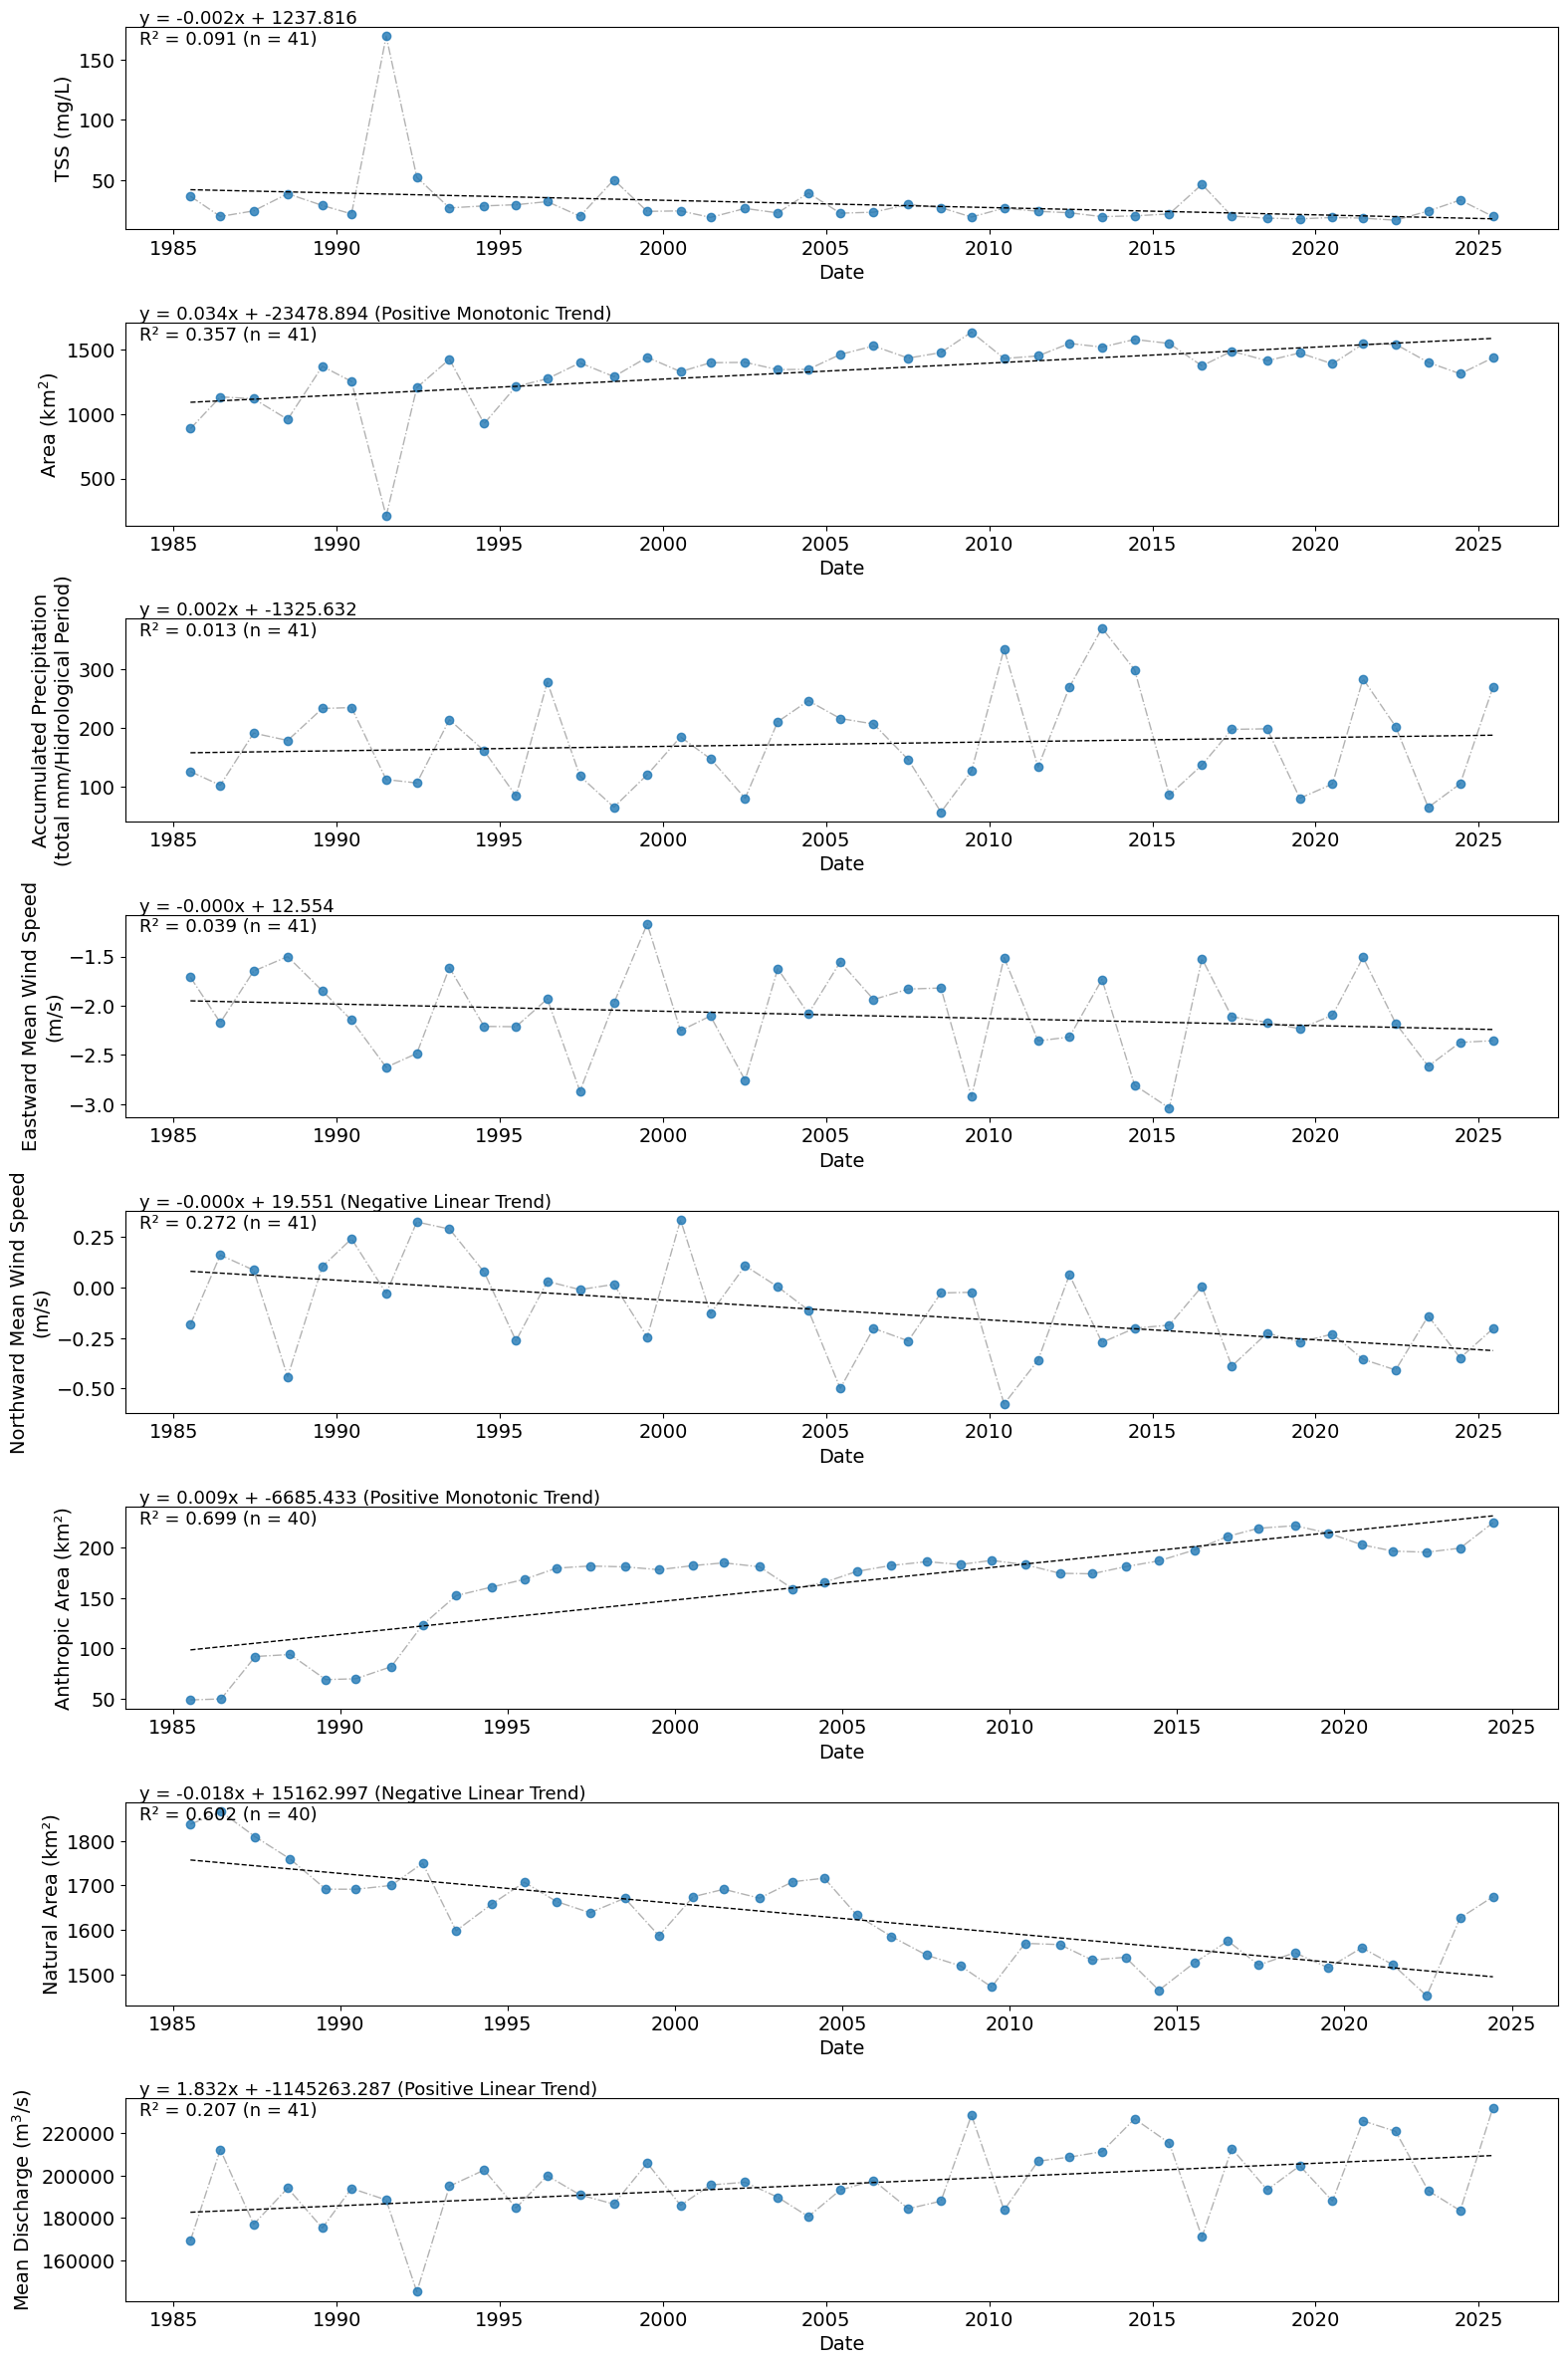


LW
Plotting for period: LW | Records: 37


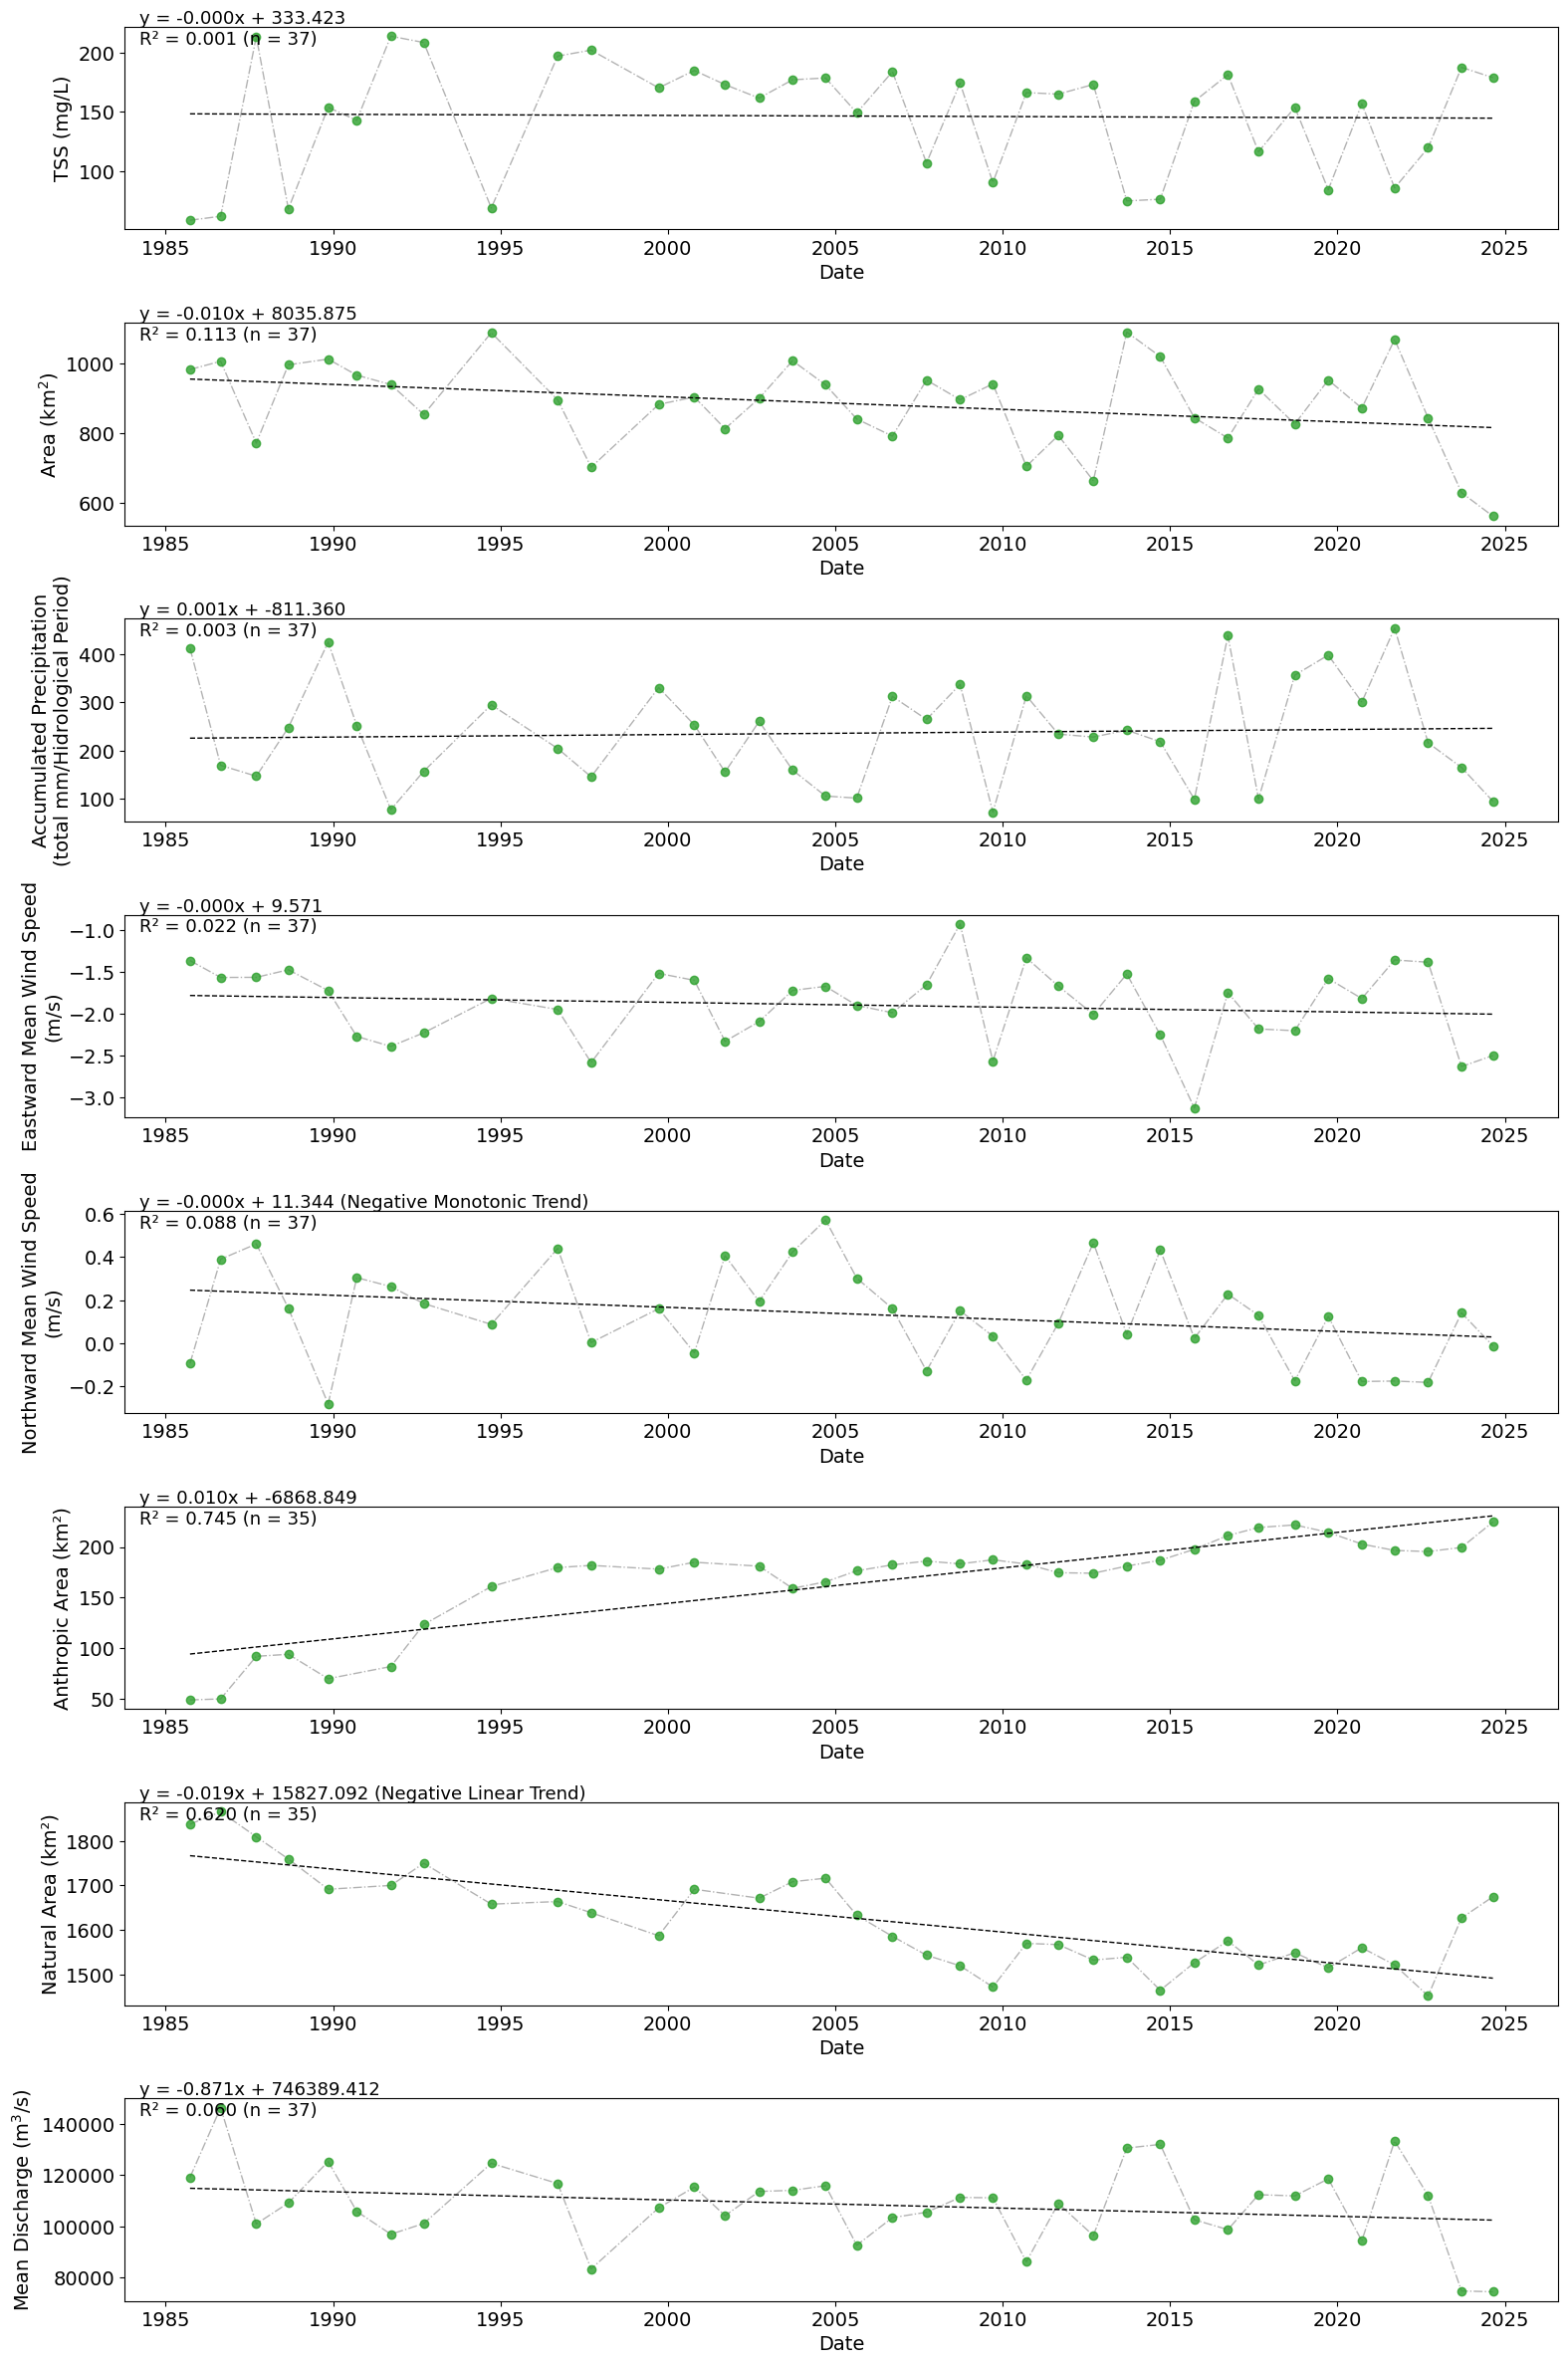

In [ ]:
# Define watersheds and water periods to process
watersheds = ["regional", "local"]  # Geographic analysis areas
water_periods = ["R", "HW", "F", "LW"]  # Rising, High Water, Falling, Low Water

# ========== Main Nested Loop: Process All Watershed x Water Period Combinations ==========
for watershed in watersheds:
    # Glob patterns to find matching files:
    # - paths_var: merged dataframe CSVs (e.g., df_merged_regional.csv, df_merged_local.csv)
    paths_var = sorted(glob.glob(f"C:/Users/l_v_v/Documents/GitHub/time_series_curuai/datasets/Parameters Time series/merged_df/*merged*{watershed}*.csv"))
    print()
    print(f"Watershed: {watershed}")
    
    # Process each water period for this watershed
    for wp in water_periods:
        # Find trend files specific to this water period
        # (e.g., regional_Watershed/trends/R.csv, regional_Watershed/trends/HW.csv, etc.)
        paths_trend = sorted(glob.glob(os.path.join(data_dir, f"{watershed}*Watershed/trends/*{wp}.csv")))
        print()
        print(f"Water Period: {wp}")
        
        # Call the water-period specific plotting function
        # This will generate separate figures for each water period x watershed combination
        prepare_time_series_plot_wp(paths_var, paths_trend, dict_var, data_dir)